<a href="https://colab.research.google.com/github/KshitijK21/My-code/blob/main/experiment__5.final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
n = int(input("Enter the number of data points: "))

X = []

print("\nEnter the data points:")

for i in range(n):
    x = float(input(f"Enter X value for point {i+1}: "))
    y = float(input(f"Enter Y value for point {i+1}: "))

    X.append([x, y])

X = np.array(X)

print("\nYour dataset:")
print(X)

Enter the number of data points: 6

Enter the data points:
Enter X value for point 1: 1
Enter Y value for point 1: 2
Enter X value for point 2: 2
Enter Y value for point 2: 1
Enter X value for point 3: 3
Enter Y value for point 3: 2
Enter X value for point 4: 8
Enter Y value for point 4: 8
Enter X value for point 5: 9
Enter Y value for point 5: 7
Enter X value for point 6: 8
Enter Y value for point 6: 9

Your dataset:
[[1. 2.]
 [2. 1.]
 [3. 2.]
 [8. 8.]
 [9. 7.]
 [8. 9.]]


In [8]:
K = int(input("\nEnter the number of clusters (K): "))

if K <= 0 or K > n:
    print("Invalid value of K")
else:
    print("K =", K)



Enter the number of clusters (K): 2
K = 2


In [10]:
centroids = []

print("\nEnter the initial centroids:")

for i in range(K):
    x = float(input(f"Enter X value for centroid {i+1}: "))
    y = float(input(f"Enter Y value for centroid {i+1}: "))

    centroids.append([x, y])

centroids = np.array(centroids)

print("\nInitial Centroids:")
print(centroids)


Enter the initial centroids:
Enter X value for centroid 1: 2
Enter Y value for centroid 1: 2
Enter X value for centroid 2: 8
Enter Y value for centroid 2: 8

Initial Centroids:
[[2. 2.]
 [8. 8.]]


In [12]:
def calculate_distance(point, centroid):
    return np.sqrt(np.sum((point - centroid) ** 2))

In [14]:
def assign_clusters(X, centroids):
    clusters = []

    for point in X:
        distances = []

        for centroid in centroids:
            distance = calculate_distance(point, centroid)
            distances.append(distance)

        nearest_centroid = np.argmin(distances)
        clusters.append(nearest_centroid)

    return np.array(clusters)

In [16]:
def calculate_centroids(X, clusters, K):

    new_centroids = []

    for i in range(K):

        cluster_points = X[clusters == i]

        if len(cluster_points) > 0:
            new_centroid = np.mean(cluster_points, axis=0)
        else:
            new_centroid = np.zeros(X.shape[1])

        new_centroids.append(new_centroid)

    return np.array(new_centroids)

In [18]:
max_iterations = 100

for iteration in range(max_iterations):

    print("\n-----------------------------")
    print("Iteration", iteration + 1)
    print("-----------------------------")


    clusters = assign_clusters(X, centroids)

    print("\nCluster assignments:")
    for i in range(len(X)):
        print(f"Point {X[i]} -> Cluster {clusters[i] + 1}")


    new_centroids = calculate_centroids(X, clusters, K)

    print("\nNew Centroids:")
    print(new_centroids)


    if np.allclose(centroids, new_centroids):

        print("\nCentroids have not changed.")
        print("Algorithm converged.")

        break


    centroids = new_centroids

else:
    print("\nMaximum number of iterations reached.")


-----------------------------
Iteration 1
-----------------------------

Cluster assignments:
Point [1. 2.] -> Cluster 1
Point [2. 1.] -> Cluster 1
Point [3. 2.] -> Cluster 1
Point [8. 8.] -> Cluster 2
Point [9. 7.] -> Cluster 2
Point [8. 9.] -> Cluster 2

New Centroids:
[[2.         1.66666667]
 [8.33333333 8.        ]]

Centroids have not changed.
Algorithm converged.


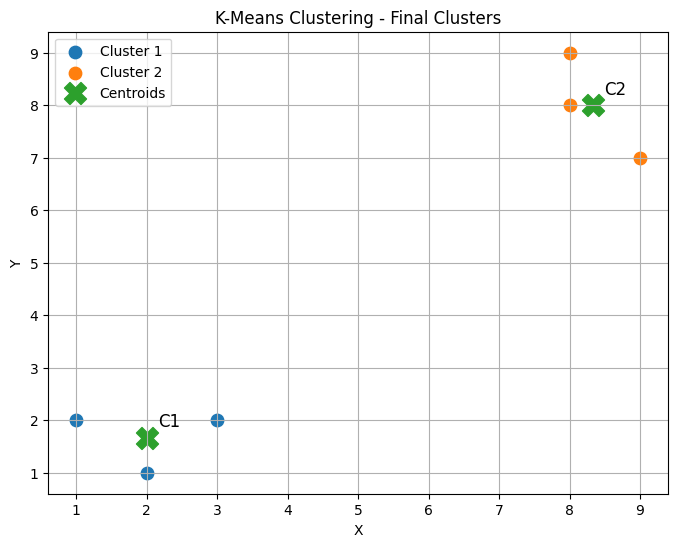

In [19]:
plt.figure(figsize=(8, 6))

# Plot each cluster
for i in range(K):
    cluster_points = X[clusters == i]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=80,
        label=f"Cluster {i + 1}"
    )

# Plot final centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)

# Add labels to centroids
for i in range(K):
    plt.annotate(
        f"C{i + 1}",
        (centroids[i, 0], centroids[i, 1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=12
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering - Final Clusters")
plt.legend()
plt.grid(True)

plt.show()